In [116]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [117]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, norm
from scipy import stats

import torch
import torch.nn as nn
from SupernovaDataset.dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset, z_obs

from SupernovaDataset.config import DATAPOINT_SIZE, LATENT_SIZE, DATA_VARIANCE_SCALE
from SupernovaDataset.config import NUM_TRAIN, NUM_TEST, LOAD_DATASET
from SupernovaDataset.config import BETA, REGULARIZATION_WEIGHT, LEARNING_RATE, OPTIM, NUM_EPOCHS, BATCH_SIZE

from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow
from Compression.ib import IB, Bounds
from Compression.mine import Mine
from Compression.tuba import TUBA, DV_with_Jensen

from Compression.Benchmarks.MOPED import moped

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance
from ModelEvaluation.abc import abc_testing, hist_with_error_bars
from ModelEvaluation.coverage_testing import coverage_tests

In [118]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cuda


In [119]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.12.0+cu132
13.2
True


In [155]:
BOUND_USED = Bounds(name="BA_KDE", cond_prob_model_class=ConditionalKDE, **{"init_std": 1, "num_kde_points": 1})
# BOUND_USED = Bounds(name="BA_NF", cond_prob_model_class=ConditionalNormalizingFlow, **{"num_flows": 5})
# BOUND_USED = Bounds(name="DV", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 0e0, "hidden_dim": 20})
# BOUND_USED = Bounds(name="DV_with_Jensen", cond_prob_model_class=DV_with_Jensen, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 5})
# BOUND_USED = Bounds(name="MINE", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 1e-2, "hidden_dim": 5})
# BOUND_USED = Bounds(name="TUBA", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 5})
# BOUND_USED = Bounds(name="NWJ", cond_prob_model_class=TUBA, **{"y_dim": 1, "z_dim": LATENT_SIZE, "hidden_dim": 400, "a": lambda z: torch.tensor(np.exp(1.0), device=device)})


## Generating a dataset

In [156]:
# LOAD_DATASET = False

In [157]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 50000 of 50000


## Visualizing the dataset

### Spread of the data with Hubble Parameter
In order to visualize the fact that our data simply moves by a global offset based on the Hubble Constant, we visualize the mean of the data with the Hubble Parameter. This forms quite a linear scatter, showing that the mean is a good representation of the parameter here!

### Each individual datapoint
Each individual datapoint retains the same shape, and only its offset depends on the Hubble constant (can be seen by re-running the cell multiple times and seeing that the shape is retained...alternatively, I can plot all the data-points and subtract their means)  
We notice that the points at low redshift scatter less than those at higher redshifts. This is expected as the lower flux due to the higher redshift appears as a larger scatter

In [158]:
mu = train_sims_data[:, :DATAPOINT_SIZE].detach().cpu()
h0 = train_sims_data[:, -1].detach().cpu()

In [159]:
mu.shape

torch.Size([10000, 100])

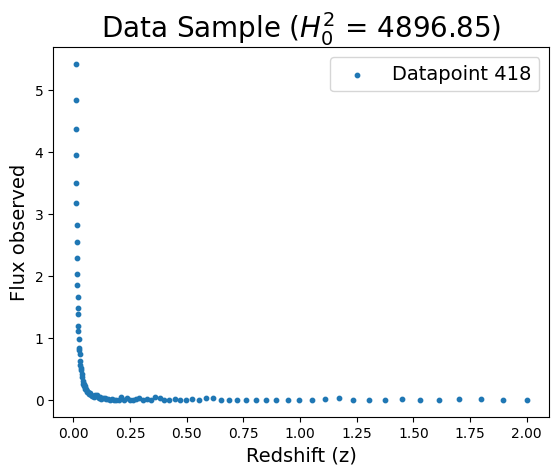

In [125]:
obs_no = np.random.randint(NUM_TRAIN)
flux_obs = 10**(-0.4*mu[obs_no, :])
mu_obs = mu[obs_no, :]
plt.scatter(z_obs, mu_obs, s=10, label=f"Datapoint {obs_no}")
# plt.yscale('log')
# plt.scatter(z_obs, mu_noiseless[obs_no, :], color='red', label='True Signal')
plt.xlabel("Redshift (z)", fontsize=14)
plt.ylabel("Flux observed", fontsize=14)
# plt.title(f"Obs: {obs_no} | H0: {h0[obs_no]:.2f}")
plt.title(f'Data Sample ($H_0^2$ = {h0[obs_no]:.2f})', fontsize=20)
plt.legend(fontsize=14)
# plt.grid()
plt.show()

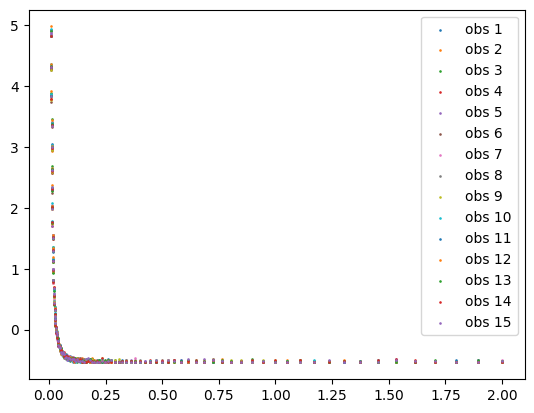

In [126]:
mu_zero_mean = mu - torch.mean(mu, axis=1)[:, None]
mu_zero_mean.shape

for i in range(15):
    plt.scatter(z_obs, mu_zero_mean[i, :], s=0.75, label=f'obs {i+1}')
plt.legend()
plt.show()

## Compression

In [160]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [161]:
model_encoder=Compressor()
model = IB(
    encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    # cond_prob_model=ConditionalKDE(1, 2),
    # cond_prob_model=Mine(1, LATENT_SIZE, alpha=5e-1),
    cond_prob_model=BOUND_USED.cond_prob_model(**BOUND_USED.cond_prob_model_kwargs),
    beta = 0e-1,
    reg_weight=4e-2,
    reg_type=0,
    optim_func=torch.optim.Adam,
    lr=1e-4
).to(device)
h02s = train_sims_data[:, -1:]
h02_norm = (h02s - h02s.mean()) / h02s.std()

Epoch 1: Loss=2.3090, log_q=-2.3090,, reg. loss=0.0000, beta * KL=38.6355
Epoch 10: Loss=2.2977, log_q=-2.2976,, reg. loss=0.0000, beta * KL=42.2288
Epoch 20: Loss=2.2871, log_q=-2.2871,, reg. loss=0.0000, beta * KL=37.9937
Epoch 30: Loss=2.2733, log_q=-2.2733,, reg. loss=0.0000, beta * KL=32.4311
Epoch 40: Loss=2.2621, log_q=-2.2621,, reg. loss=0.0000, beta * KL=19.2704
Epoch 50: Loss=2.2523, log_q=-2.2522,, reg. loss=0.0000, beta * KL=34.2302
Epoch 60: Loss=2.2412, log_q=-2.2412,, reg. loss=0.0000, beta * KL=20.2613
Epoch 70: Loss=2.2299, log_q=-2.2299,, reg. loss=0.0000, beta * KL=19.6638
Epoch 80: Loss=2.2186, log_q=-2.2185,, reg. loss=0.0000, beta * KL=16.5537
Epoch 90: Loss=2.2091, log_q=-2.2091,, reg. loss=0.0000, beta * KL=28.7761
Epoch 100: Loss=2.1987, log_q=-2.1987,, reg. loss=0.0000, beta * KL=23.3716
Epoch 110: Loss=2.1872, log_q=-2.1872,, reg. loss=0.0000, beta * KL=13.1635
Epoch 120: Loss=2.1764, log_q=-2.1764,, reg. loss=0.0000, beta * KL=15.0566
Epoch 130: Loss=2.1750,

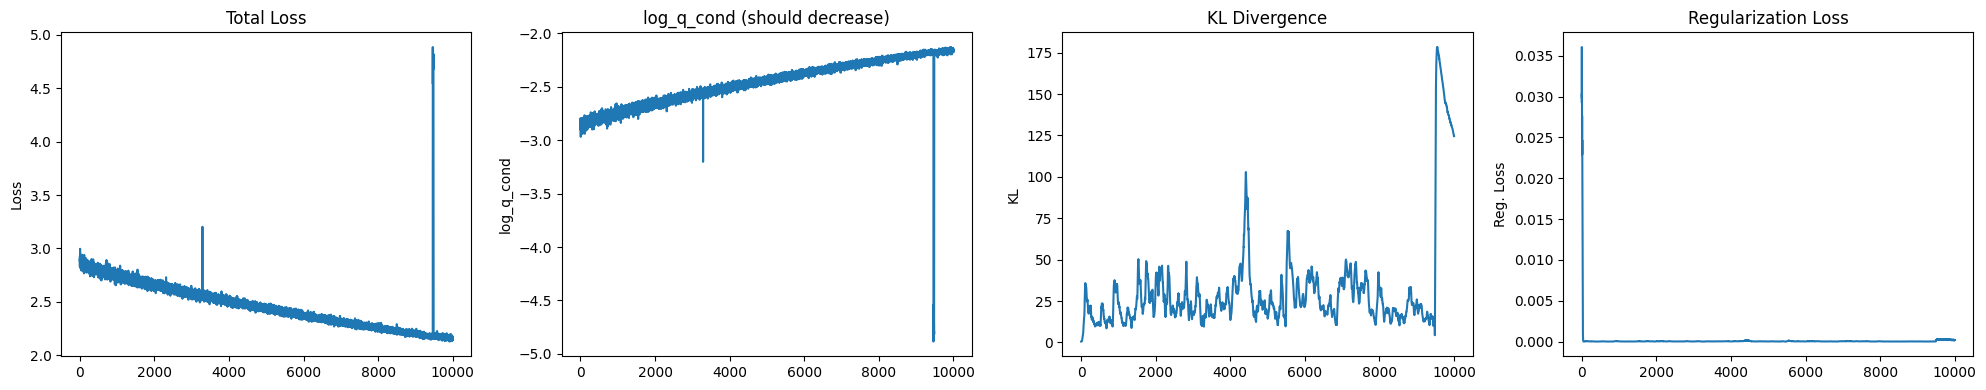

In [186]:
model.train(
    x_train=train_sims_data[:, :DATAPOINT_SIZE],
    y_train=h02_norm,
    nepochs=150,
    batch_size=512,
    print_losses=True
    )

assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

In [187]:
zs = model.encoder(test_sims_data[:, :DATAPOINT_SIZE])[-1].detach().cpu()
z_min = zs.min()
z_max = zs.max()

print(f"Latent space range: min={z_min:.4f}, max={z_max:.4f}")

# z_min = -10
# z_max = 10

y_max = 3
y_min = -1 * y_max

z_values = torch.linspace(z_min, z_max, 101)
z_mean_train = zs.mean()
z_std_train = zs.std()
z_normalized = (z_values - z_mean_train) / z_std_train
y_values = torch.linspace(y_min, y_max, 101)

# Create a 2D grid explicitly (Z rows, Y columns)
Z_grid, Y_grid = torch.meshgrid(z_normalized, y_values, indexing='ij')

# Stack them to feed into your model: shape is (100, 100, 2) -> flatten to (10000, 2)
yz_values = torch.stack([Y_grid, Z_grid], dim=-1).reshape(-1, 2).to(device)

dy = y_values[1] - y_values[0]  # Assuming uniform spacing

Latent space range: min=12.4071, max=13.0334


In [165]:
model.cond_prob_model.off_diag_L

Parameter containing:
tensor([-0.3917], device='cuda:0', requires_grad=True)

In [166]:
torch.log_softmax(model.cond_prob_model.raw_weights, dim=0).exp()

tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>)

<>:14: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:14: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\srish\AppData\Local\Temp\ipykernel_16800\994397848.py:14: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  plt.ylabel(f"$\Theta$", fontsize=14)


tensor(25.0435) tensor(4899.9629)
tensor([9.8531e-06, 1.5667e-05, 2.4598e-05, 3.8141e-05, 5.8415e-05, 8.8388e-05,
        1.3215e-04, 1.9528e-04, 2.8525e-04, 4.1196e-04, 5.8835e-04, 8.3110e-04,
        1.1614e-03, 1.6060e-03, 2.1977e-03, 2.9767e-03, 3.9916e-03, 5.2996e-03,
        6.9679e-03, 9.0738e-03, 1.1704e-02, 1.4957e-02, 1.8937e-02, 2.3758e-02,
        2.9537e-02, 3.6392e-02, 4.4438e-02, 5.3785e-02, 6.4525e-02, 7.6733e-02,
        9.0455e-02, 1.0570e-01, 1.2246e-01, 1.4064e-01, 1.6012e-01, 1.8074e-01,
        2.0226e-01, 2.2439e-01, 2.4681e-01, 2.6913e-01, 2.9096e-01, 3.1187e-01,
        3.3140e-01, 3.4915e-01, 3.6469e-01, 3.7765e-01, 3.8773e-01, 3.9467e-01,
        3.9829e-01, 3.9849e-01, 3.9528e-01, 3.8874e-01, 3.7903e-01, 3.6639e-01,
        3.5115e-01, 3.3365e-01, 3.1430e-01, 2.9354e-01, 2.7180e-01, 2.4951e-01,
        2.2709e-01, 2.0490e-01, 1.8330e-01, 1.6255e-01, 1.4292e-01, 1.2458e-01,
        1.0765e-01, 9.2214e-02, 7.8307e-02, 6.5919e-02, 5.5005e-02, 4.5495e-02,
      

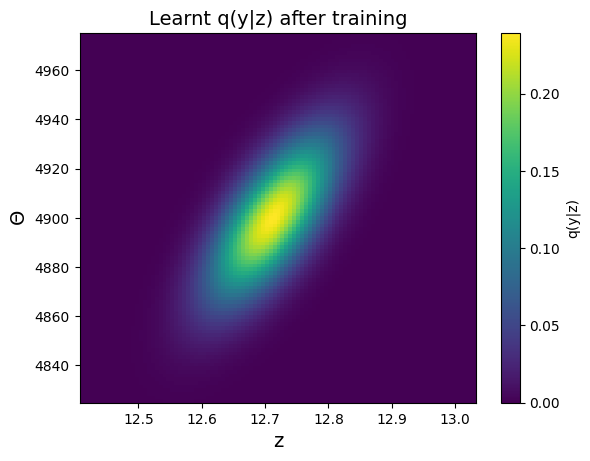

In [188]:
log_q_flat = model.cond_prob_model(yz_values[:, 1:], yz_values[:, 0:1]).detach().cpu()
log_q_values = log_q_flat.reshape(101, 101)
q_values = log_q_values.exp()

y_scale =  h02s.std().detach().cpu()
y_mean = h02s.mean().detach().cpu()
print(y_scale, y_mean)

print((q_values * dy).sum(dim=1))  # Should be close to 1 for each z
plt.imshow(q_values.T, extent=[z_min, z_max, (y_min * y_scale) + y_mean, (y_max * y_scale) + y_mean], origin='lower', aspect='auto')
plt.colorbar(label='q(y|z)')
plt.title("Learnt q(y|z) after training", fontsize=14)
plt.xlabel("z", fontsize=14)
plt.ylabel(f"$\Theta$", fontsize=14)
plt.show()

tensor(26.9999)

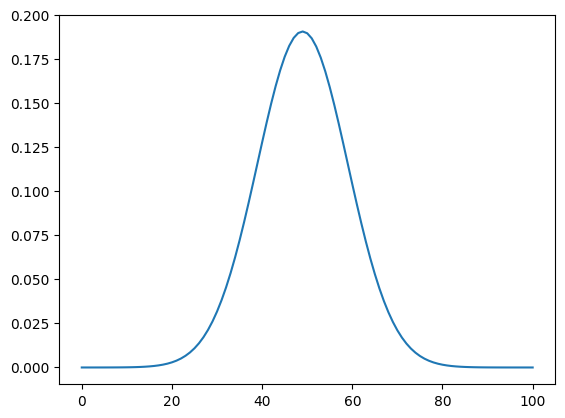

In [168]:
# plt.plot(q_values[51, :])
plt.plot(q_values[:, 51])

(q_values[:, 51]).std() * y_scale / dy

In [135]:
# Evaluate model
log_q_flat = 1e1 * model.cond_prob_model.T(yz_values).detach().cpu()
log_q_values = log_q_flat.reshape(101, 101)


# Compute analytical factor safely over the Y_grid matrix 
# (Y_grid ensures broadcasting lines up perfectly with columns)
analytical_factor = torch.exp(-0.5 * (Y_grid ** 2)) / np.sqrt(2 * np.pi)
Z_z = (torch.exp(log_q_values) * analytical_factor).sum(dim=1, keepdim=True) * dy   # shape (100, 1), indexed by z
print(Z_z.shape)

q_values = torch.exp(log_q_values) * analytical_factor  / Z_z
print((q_values * dy).sum(dim=1))  # Should be close to 1 for each z

# Plotting
plt.imshow(q_values.numpy(), extent=(y_min, y_max, z_min, z_max), origin='lower', aspect='auto')
plt.colorbar(label='q(y|z)')
plt.title("Learnt q(y|z) after training")
plt.ylabel("z")
plt.xlabel("y")
plt.show()

AttributeError: 'ConditionalNormalizingFlow' object has no attribute 'T'

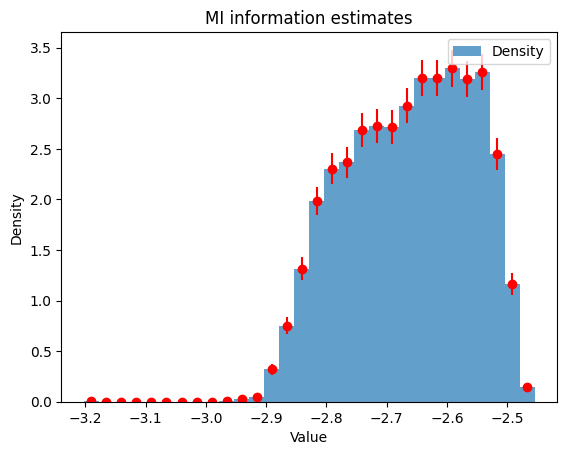

In [169]:
hist_with_error_bars(model.log_prob_losses, title='MI information estimates')

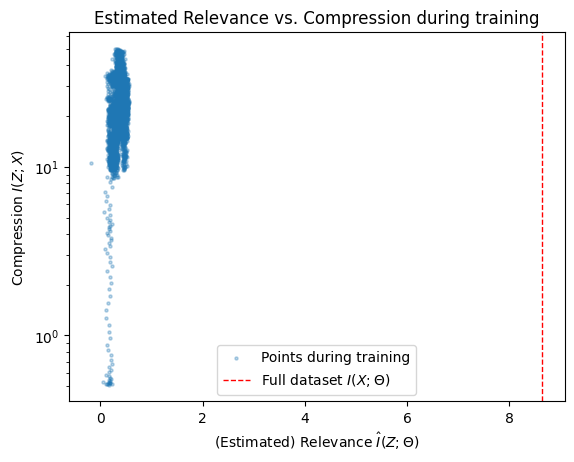

In [170]:
plt.scatter(np.array(model.log_prob_losses) + 3.02, np.array(model.kl_losses), alpha=0.3, s=5e0,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)

plt.yscale('log')
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

## Running loops for Information Plane

In [171]:
NUM_EPOCHS=10

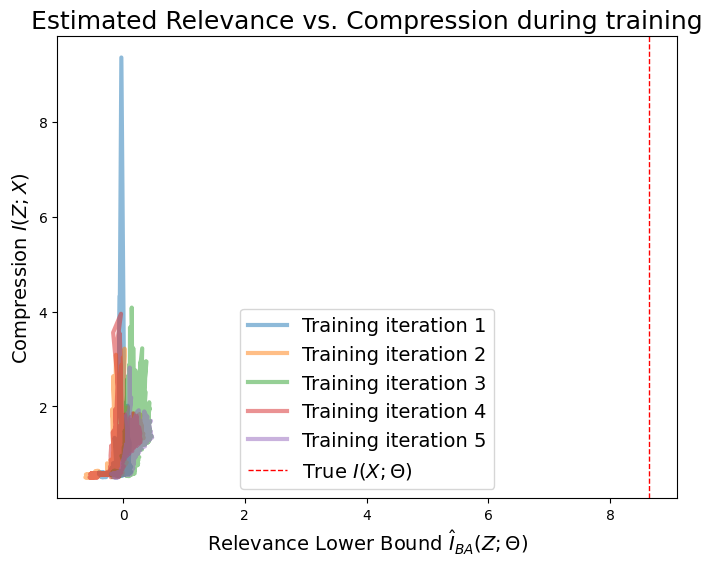

In [172]:
n_runs = 0
load_existing = True

if load_existing:
    try:
        n_old_runs = np.load(f"{BOUND_USED.name}_bound/n_runs.npy", allow_pickle=True)
        bounds = np.load(f"{BOUND_USED.name}_bound/{BOUND_USED.name}_bounds.npy", allow_pickle=True).tolist()
        i_z_x = np.load(f"{BOUND_USED.name}_bound/i_z_x.npy", allow_pickle=True).tolist()
    except FileNotFoundError:
        n_old_runs = 0
        bounds = []
        i_z_x = []
else:
    n_old_runs = 0
    bounds = []
    i_z_x = []

for i in range(n_runs):
    print(f"Training new model iteration {i+1}...")
    model_encoder=Compressor()
    model = IB(
        encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        cond_prob_model=BOUND_USED.cond_prob_model(**BOUND_USED.cond_prob_model_kwargs),
        beta = BETA,
        reg_weight=REGULARIZATION_WEIGHT,
        reg_type=0,
        optim_func=OPTIM,
        lr=LEARNING_RATE
    ).to(device)

    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=h02_norm,
        nepochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        print_losses=True
        )
    assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

    bounds = bounds + [model.log_prob_losses]
    i_z_x = i_z_x + [model.kl_losses]

plt.figure(figsize=(8, 6))
for i in range(5):
    plt.plot(np.array(bounds[i]) + 3.02, np.array(i_z_x[i]), alpha=0.5,
             label=f'Training iteration {i+1}', linewidth=3 #, s=1e0,
         )
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'True $I(X; \Theta)$'
)
plt.xlabel(r"Relevance Lower Bound $\hat{I}_{BA}(Z;\Theta)$", fontsize=14)
plt.ylabel(r"Compression $I(Z;X)$", fontsize=14)
plt.legend(fontsize=14, loc='best')
plt.title('Estimated Relevance vs. Compression during training', fontsize=18)
plt.show()

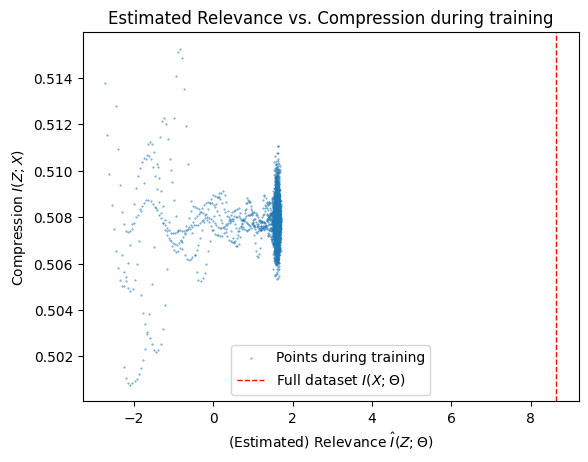

In [141]:
plt.scatter(np.array(bounds[-n_runs:]) + 3.02, i_z_x[-n_runs:], alpha=0.75, s=2e-1,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
# plt.xlim([-15, 15])
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

In [142]:
len(bounds[0]), len(bounds[-1])

(2000, 2000)

In [173]:
if not os.path.exists(f"{BOUND_USED.name}_bound"):
    os.makedirs(f"{BOUND_USED.name}_bound")
if not len(bounds) == 0:
    np.save(f"{BOUND_USED.name}_bound/{BOUND_USED.name}_bounds.npy", np.array(bounds), allow_pickle=True)
    np.save(f"{BOUND_USED.name}_bound/i_z_x.npy", i_z_x, allow_pickle=True)
    np.save(f"{BOUND_USED.name}_bound/n_runs.npy", n_old_runs + n_runs,
            allow_pickle=True)

## Plotting the results to compare estimator std dev

12.973975 12.42172


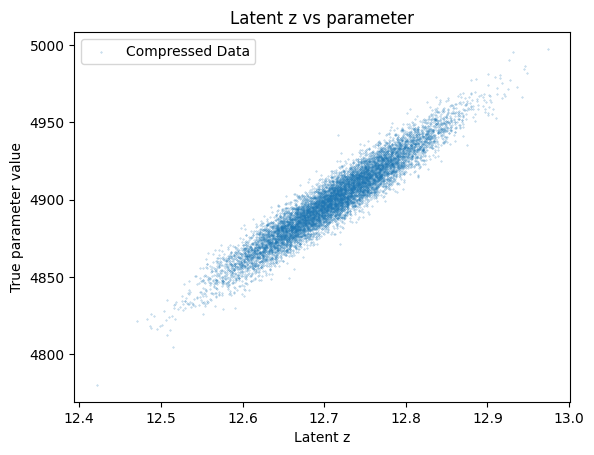

In [189]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
m = m.detach().cpu().numpy()

print(m.max(), m.min())

plt.scatter(m, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([110, 120])
plt.title('Latent z vs parameter')
plt.show()

In [190]:
# To check if the model collapsed: the standard deviations in m must match the priors
m.std(), l.std()


(np.float32(0.06741257),
 tensor(0.4618, device='cuda:0', grad_fn=<StdBackward0>))

Dataset size: 50000, Number of bins: 11, Bin width: 0.01
Bin centers: [12.435578 12.492514 12.549448 12.606382 12.663317 12.720252 12.777187
 12.834122 12.891056 12.94799  13.004926]
Bin means: [4825.7099609375, 4822.51318359375, 4843.82177734375, 4862.5107421875, 4882.95654296875, 4902.85400390625, 4922.84326171875, 4943.3330078125, 4965.21484375, 4987.31494140625, nan]
Bin stds: [0.0, 7.309604644775391, 6.870363235473633, 7.440530300140381, 7.32369327545166, 7.550019264221191, 7.743223667144775, 7.5658087730407715, 6.955704689025879, 5.846411228179932, nan]
Bin stds errors: [nan, np.float64(1.4335314123214682), np.float64(0.47637397935697806), np.float64(0.21940926845649633), np.float64(0.13618554180090905), np.float64(0.12408801934570785), np.float64(0.16397187875415212), np.float64(0.2884437553246489), np.float64(0.8561880609841314), np.float64(2.0670185125256006), nan]


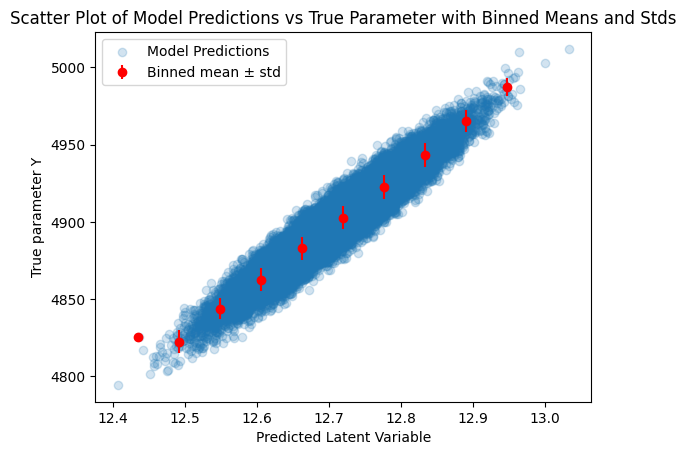

(np.float64(7.491539745138765),
 array([7.30960464, 6.87036324, 7.4405303 , 7.32369328, 7.55001926,
        7.74322367, 7.56580877, 6.95570469, 5.84641123]),
 array([1.43353141, 0.47637398, 0.21940927, 0.13618554, 0.12408802,
        0.16397188, 0.28844376, 0.85618806, 2.06701851]))

In [191]:
sigma_beta, _, std, std_err = evaluate_posterior_covariance(model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])
sigma_beta, std, std_err

## Posterior comparison

In [177]:
SELECT_PERCENT = 0.175e-3
show_h0_instead_of_h02 = False
true_h02 = 70.**2

In [178]:

# true_h0 = test_sims_data[0, -1].item()
_, data_obs, _, _ = create_synthetic_supernovae_dataset(n_samples=1, h02s=[true_h02])
data_obs = torch.tensor(data_obs, dtype=torch.float32).to(device)

y_data_abc = test_sims_data[:, -1:].detach().cpu()
shown_true_param = true_h02
param_name = '$H_0^2$' if not show_h0_instead_of_h02 else '$H_0$'

if show_h0_instead_of_h02:
    y_data_abc = torch.sqrt(y_data_abc)
    shown_true_param = np.sqrt(true_h02)


Creating sample: 1 of 1


Compressed obs: 3.1143839359283447
Selected 1285 samples from test set with compressed value close to observed compressed value.


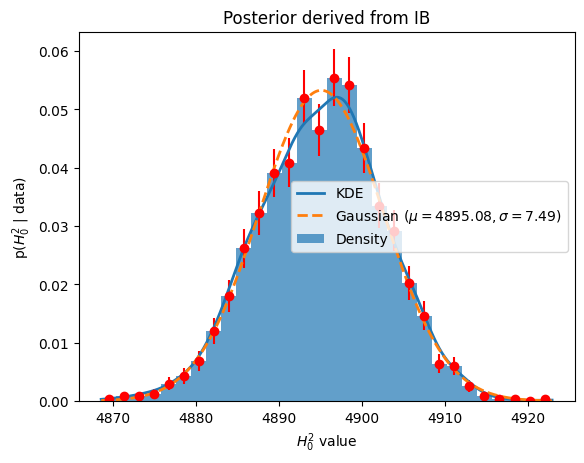

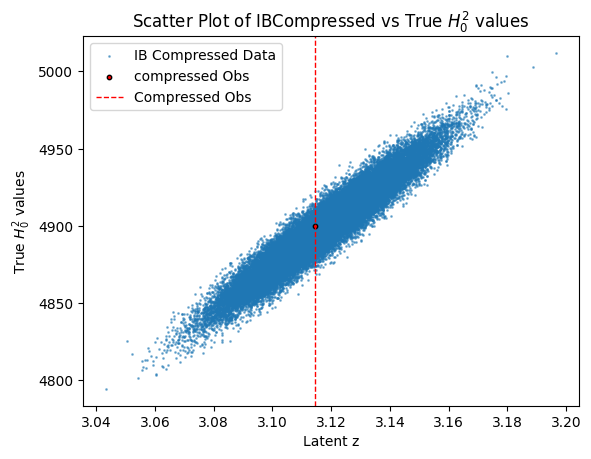

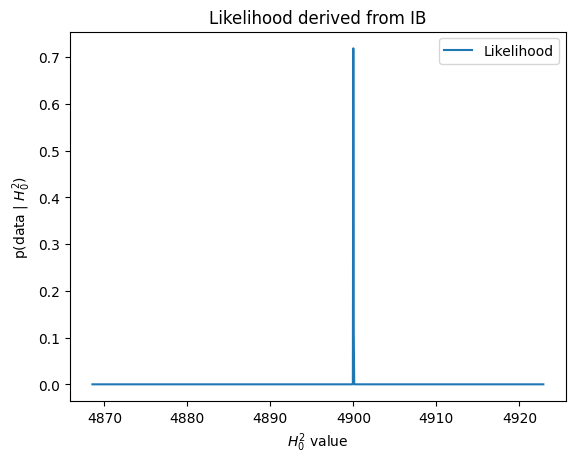

((np.float32(4895.076), np.float32(7.4911084)),
 0.6572896838188171,
 0.7439688715953308,
 1285)

In [179]:
compressed_test = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu().numpy()

compressed_obs = model(data_obs).detach().cpu().numpy()

print("Compressed obs:", compressed_obs.item())

abc_testing(compressed_obs, compressed_test, 
            y_data=y_data_abc,
            true_param=shown_true_param,
            param_name=param_name,
            select_percent=SELECT_PERCENT,
            method_name='IB')

### MOPED Compression

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)
MOPED Fisher information: [[1.6e-07]]


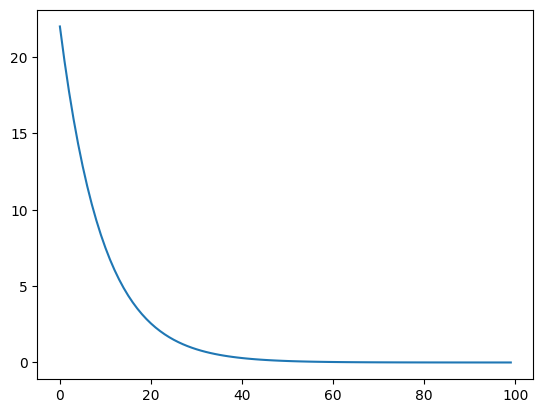

In [150]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]

fid_vals = np.array([70.0**2])

b, F, d = moped(fid_vals, cov, estimator_given_theta)
# print("MOPED compressed value:", b)
print("MOPED Fisher information:", 1/F)
plt.plot(b.T)
plt.show()

In [180]:
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data.detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T
moped_compressed = moped_model(data_obs)
moped_test = moped_model(test_sims_data)
moped_compressed

array([[614.85909704]])

Selected 1813 samples from test set with compressed value close to observed compressed value.


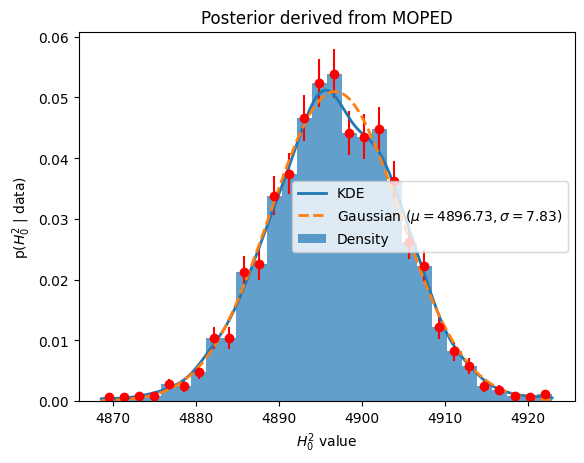

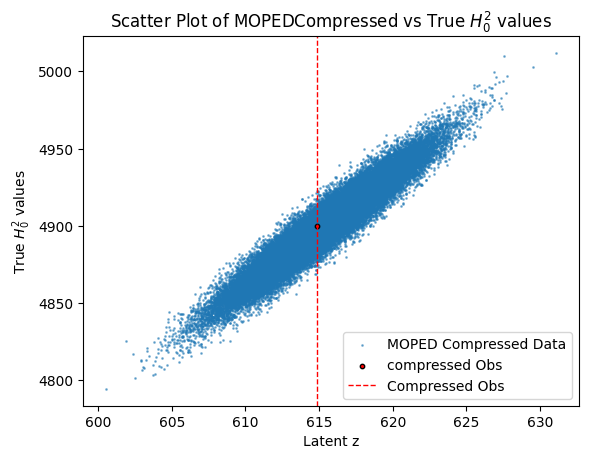

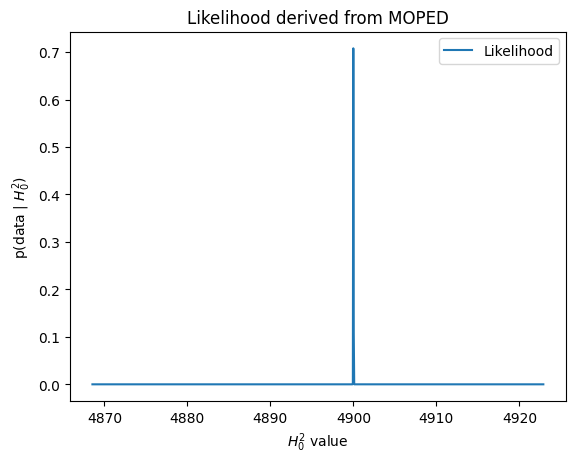

((np.float32(4896.7334), np.float32(7.8277154)),
 0.41731226444244385,
 0.6541643684500827,
 1813)

In [181]:
abc_testing(moped_compressed, moped_test, y_data_abc, true_param=shown_true_param)

# Coverage Testing

Creating sample: 5000 of 5000
Creating sample: 1 of 1


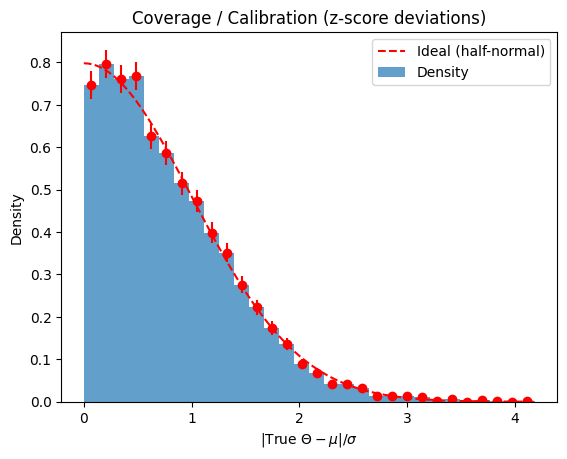

Fraction within 1σ: 0.680  (ideal ≈ 0.683)
Fraction within 2σ: 0.957  (ideal ≈ 0.954)


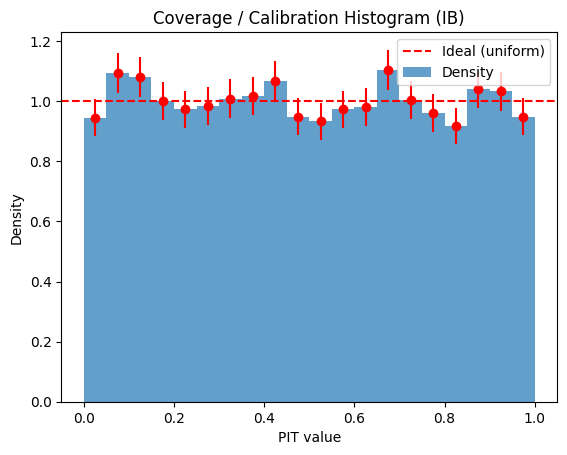

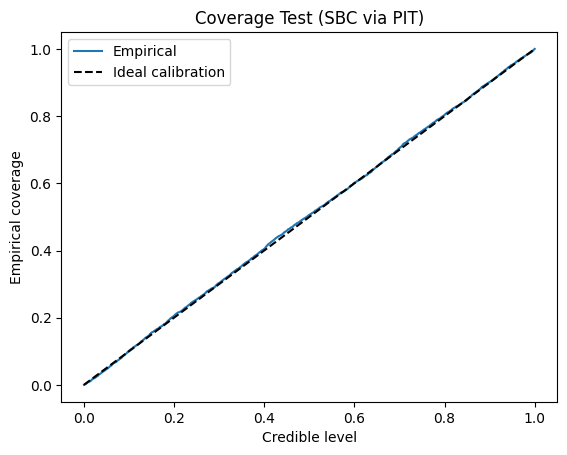

In [182]:
z_scores, pit_values= coverage_tests(5000, model, test_sims_data, "IB")

Creating sample: 5000 of 5000
Creating sample: 1 of 1


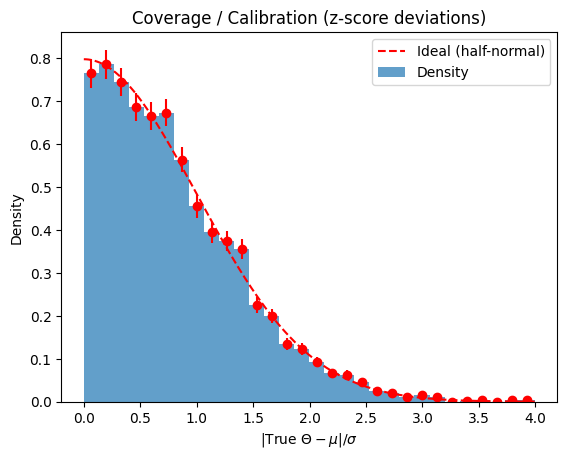

Fraction within 1σ: 0.682  (ideal ≈ 0.683)
Fraction within 2σ: 0.952  (ideal ≈ 0.954)


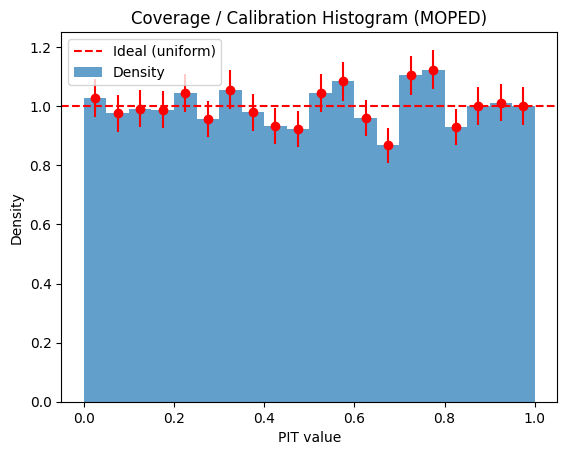

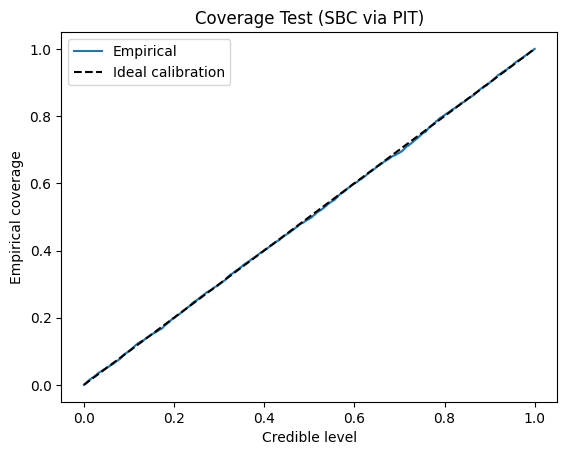

(array([0.70689863, 0.7011103 , 0.5285843 , ..., 0.90778136, 1.96987116,
        0.66668922], shape=(5000,)),
 array([0.24092482, 0.24242485, 0.70293406, ..., 0.81633633, 0.97322407,
        0.74599492], shape=(5000,)))

In [154]:
coverage_tests(5000, moped_model, test_sims_data, "MOPED")